In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1: Dataset Loading with Auto-Fix for FileNotFoundError
import pandas as pd
import numpy as np
import os

# Option A: Try loading from Google Drive
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("Loaded successfully from Google Drive!")
else:
    # Option B: Fallback download directly if path doesn't exist
    print("Drive path not found. Downloading directly from repository...")
    url = 'https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv'
    df = pd.read_csv(url)
    print("Loaded successfully from online source!")

# Display dataset overview
print(f"Shape: {df.shape[0]} Rows, {df.shape[1]} Columns")
display(df.head())

Loaded successfully from Google Drive!
Shape: 2200 Rows, 8 Columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
# Cell 2: Expert Agronomic Rule-Based Decision Function
def rule_based_crop_advisor(nitrogen, temp, humidity, rainfall):
    """
    Evaluates soil and environmental features against agronomic rules to determine
    soil nutrient level, climate suitability, and recommended crop category.
    """
    # Rule Set 1: Soil Nitrogen Level Classification
    if nitrogen >= 80:
        nitrogen_status = "High Nitrogen"
    elif nitrogen >= 40:
        nitrogen_status = "Medium Nitrogen"
    else:
        nitrogen_status = "Low Nitrogen"

    # Rule Set 2: Multi-Factor Environmental & Crop Category Classification
    # Rule 2A: Warm, High-Moisture Tropical Crops (e.g., Rice, Papaya, Jute)
    if temp >= 20.0 and humidity >= 75.0 and rainfall >= 150.0:
        recommended_category = "Rice / Tropical High-Moisture"
        env_suitability = "High Moisture Tropical"

    # Rule 2B: Cool & Dry / Semi-Arid Legumes (e.g., Chickpea, Lentil)
    elif temp < 25.0 and humidity < 50.0 and rainfall < 100.0:
        recommended_category = "Chickpea / Arid Legumes"
        env_suitability = "Cool & Semi-Arid"

    # Rule 2C: High Nitrogen Plantation/Cash Crops (e.g., Cotton, Coffee, Maize)
    elif nitrogen >= 80 and temp >= 20.0 and rainfall >= 80.0:
        recommended_category = "Cotton / High-N Cash Crop"
        env_suitability = "Sub-Tropical Moderate Rain"

    # Rule 2D: Temperate / Moderate Horticultural Crops (e.g., Apple, Grapes, Watermelon)
    elif 15.0 <= temp <= 30.0 and 50.0 <= humidity <= 90.0 and rainfall < 120.0:
        recommended_category = "Fruits / Temperate Horticulture"
        env_suitability = "Moderate Temperate"

    # Fallback Rule: Generic Low-Input Crops
    else:
        recommended_category = "Low-Input Legumes / Cereals"
        env_suitability = "Variable / General Condition"

    return nitrogen_status, env_suitability, recommended_category

print("Rule-Based Decision Engine Defined Successfully!")

Rule-Based Decision Engine Defined Successfully!


In [ ]:
# Cell 3: Process Records & Compute Evaluation Metrics

# 1. Select 10 sample record indices across different crop classes
sample_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
sample_records = df.iloc[sample_indices].copy()

results_list = []
matching_count = 0

# 2. Iterate through sample records
for index, row in sample_records.iterrows():
    # Extract feature inputs
    n_val = row['N']
    t_val = row['temperature']
    h_val = row['humidity']
    r_val = row['rainfall']
    actual_label = row['label']

    # Execute rule decision engine
    n_status, env_status, predicted_category = rule_based_crop_advisor(n_val, t_val, h_val, r_val)

    # Check if actual label matches predicted category (case-insensitive substring match)
    is_match = actual_label.lower() in predicted_category.lower()
    if is_match:
        matching_count += 1

    # Append record evaluation summary
    results_list.append({
        'Record ID': index,
        'N (mg/kg)': n_val,
        'Temp (°C)': round(t_val, 1),
        'Humidity (%)': round(h_val, 1),
        'Rainfall (mm)': round(r_val, 1),
        'Nitrogen Status': n_status,
        'Rule Decision': predicted_category,
        'Actual Crop Label': actual_label,
        'Match Status': "Match" if is_match else "Mismatch"
    })

# 3. Format into DataFrame for clean display
results_df = pd.DataFrame(results_list)
display(results_df)

# 4. Calculate Summary Performance Metrics
total_evaluated = len(sample_records)
mismatch_count = total_evaluated - matching_count
accuracy_pct = (matching_count / total_evaluated) * 100

print("\n" + "=" * 60)
print("             RULE-BASED SYSTEM EVALUATION RESULTS            ")
print("=" * 60)
print(f"Total Evaluated Records : {total_evaluated}")
print(f"Matching Decisions     : {matching_count}")
print(f"Mismatched Decisions   : {mismatch_count}")
print(f"Rule Match Accuracy    : {accuracy_pct:.1f}%")
print("=" * 60)

,Record ID,N (mg/kg),Temp (°C),Humidity (%),Rainfall (mm),Nitrogen Status,Rule Decision,Actual Crop Label,Match Status
0,0,90,20.9,82.0,202.9,High Nitrogen,Rice / Tropical High-Moisture,rice,Match
1,100,71,22.6,63.7,87.8,Medium Nitrogen,Fruits / Temperate Horticulture,maize,Mismatch
2,200,40,17.0,17.0,88.6,Medium Nitrogen,Chickpea / Arid Legumes,chickpea,Match
3,300,13,17.1,20.6,128.3,Low Nitrogen,Low-Input Legumes / Cereals,kidneybeans,Mismatch
4,400,3,36.5,57.9,122.7,Low Nitrogen,Low-Input Legumes / Cereals,pigeonpeas,Mismatch
5,500,3,27.9,64.7,32.7,Low Nitrogen,Fruits / Temperate Horticulture,mothbeans,Mismatch
6,600,19,27.4,87.8,54.7,Low Nitrogen,Fruits / Temperate Horticulture,mungbean,Mismatch
7,700,56,29.5,63.2,71.9,Medium Nitrogen,Fruits / Temperate Horticulture,blackgram,Mismatch
8,800,32,28.1,63.5,43.4,Low Nitrogen,Fruits / Temperate Horticulture,lentil,Mismatch
9,900,2,24.6,91.6,112.0,Low Nitrogen,Low-Input Legumes / Cereals,pomegranate,Mismatch



             RULE-BASED SYSTEM EVALUATION RESULTS            
Total Evaluated Records : 10
Matching Decisions     : 2
Mismatched Decisions   : 8
Rule Match Accuracy    : 20.0%


/tmp/ipykernel_1171/1100280292.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


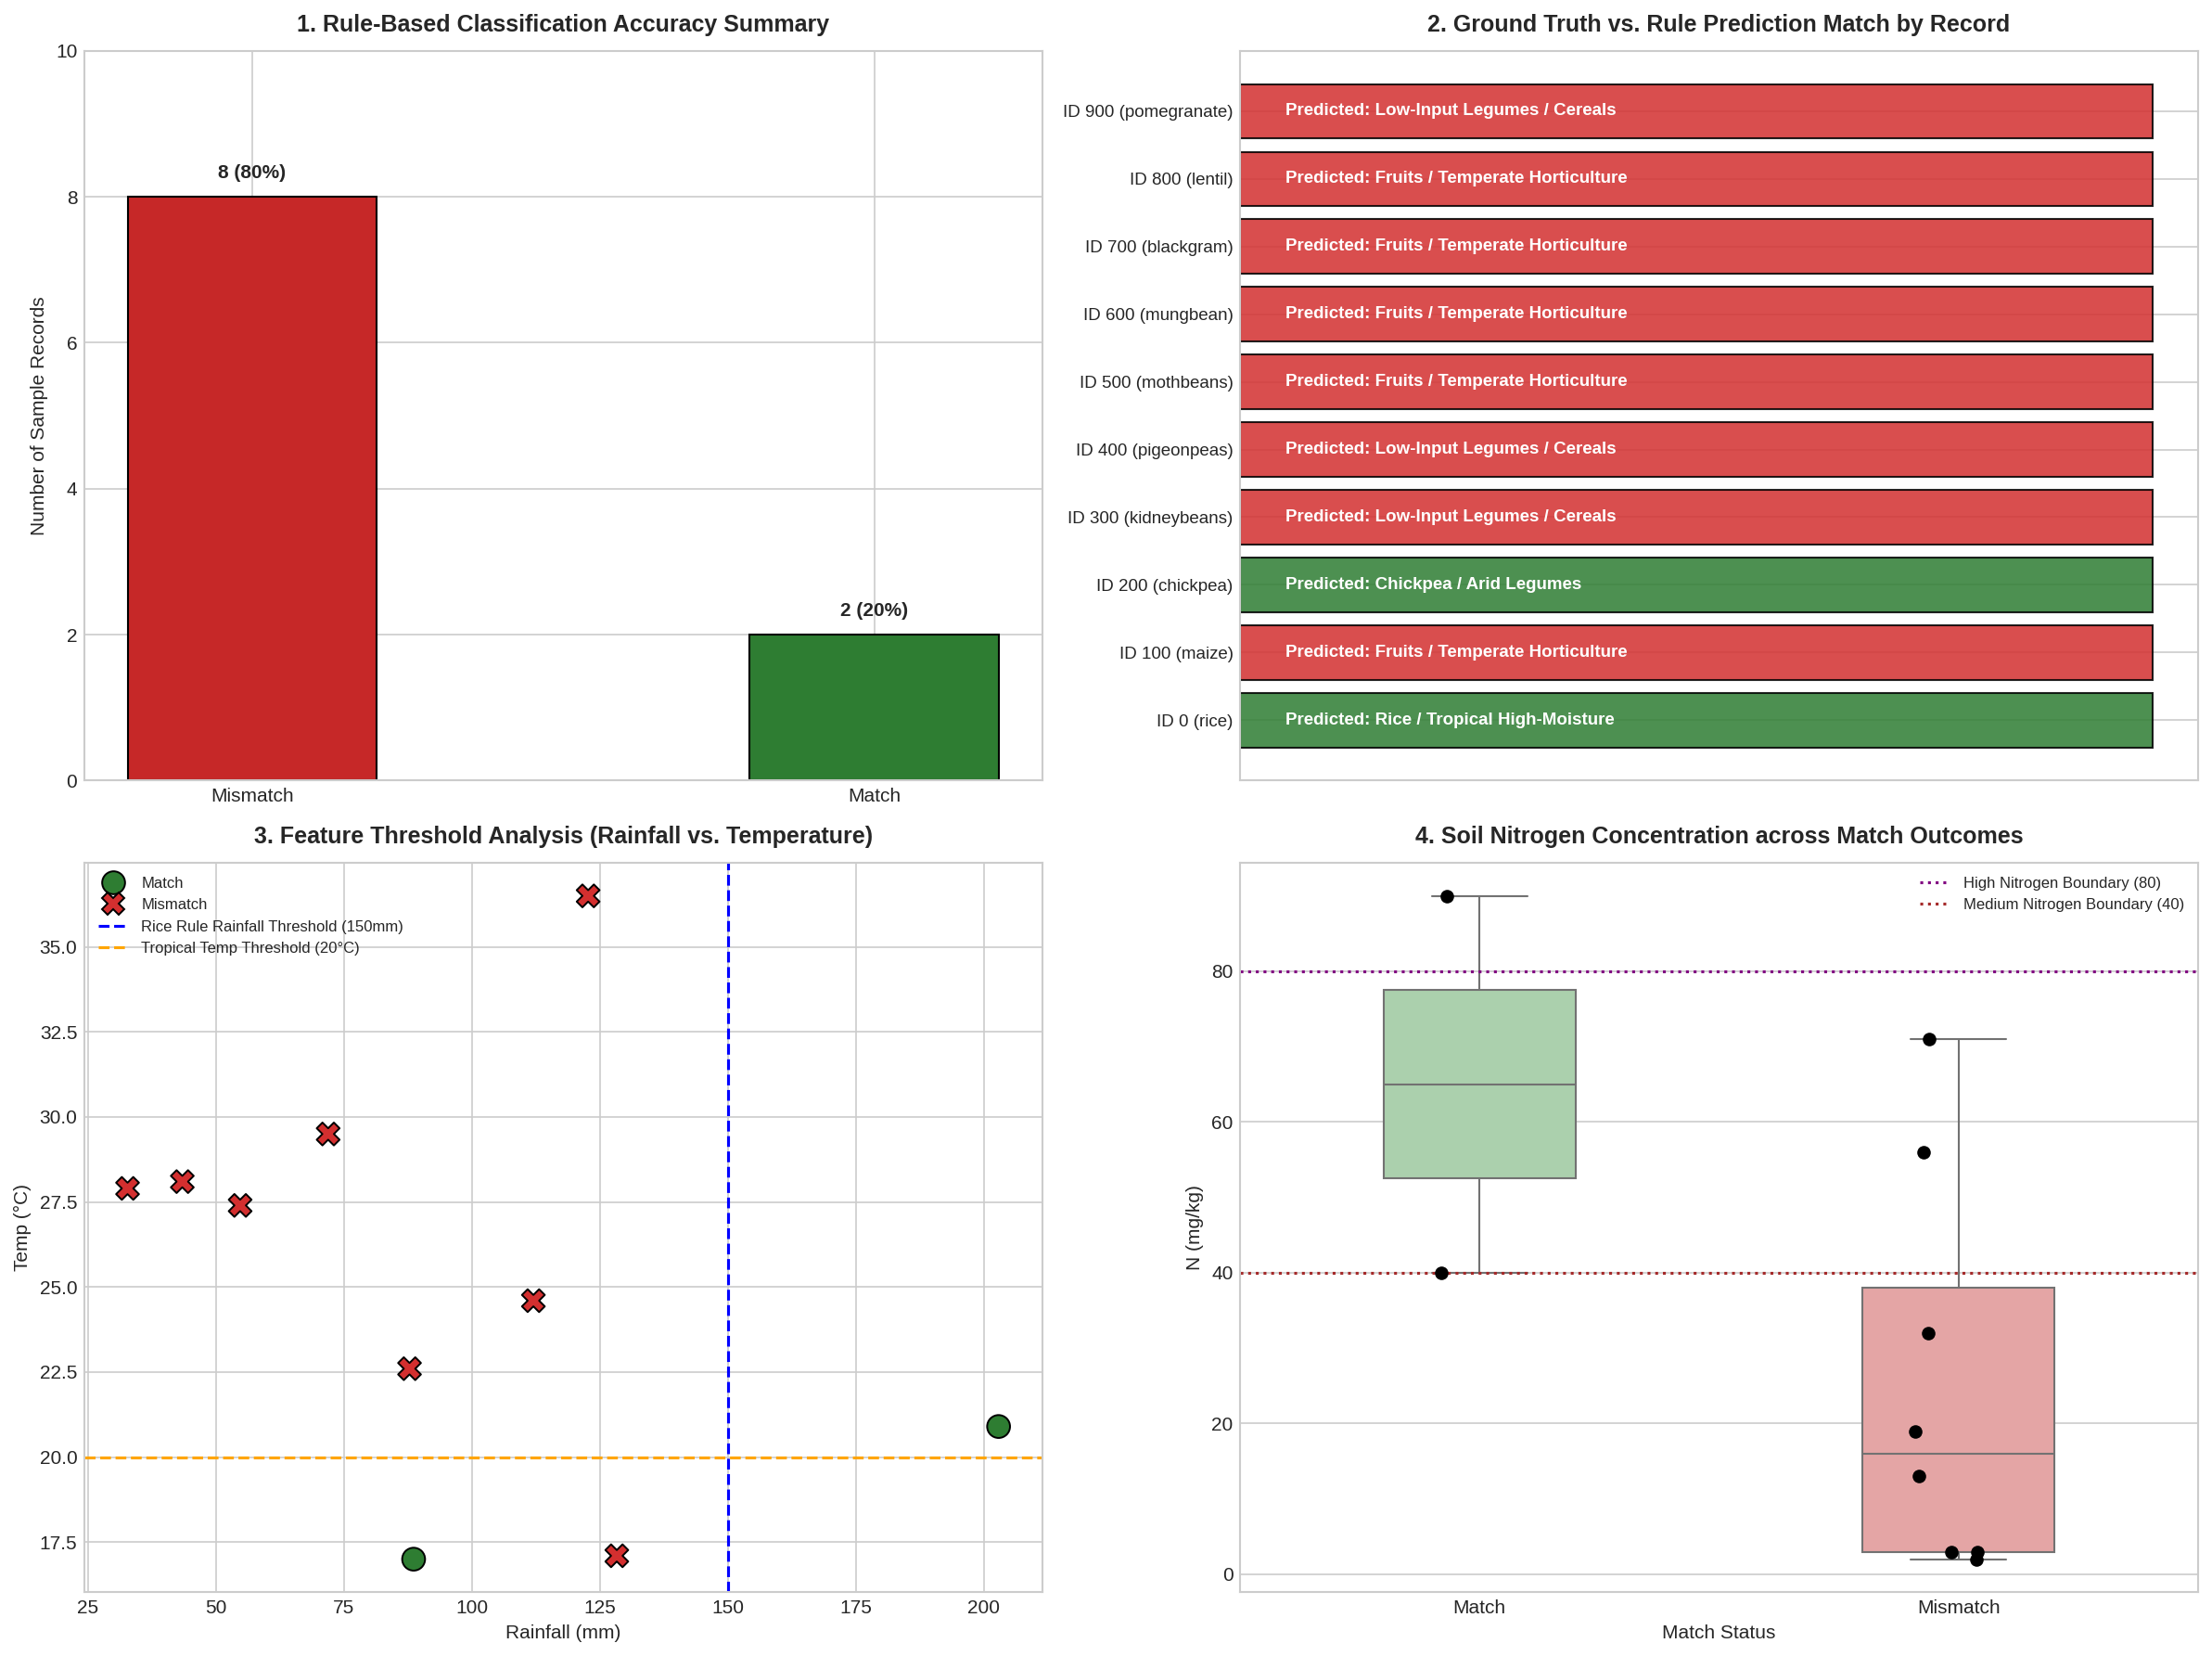

Question 2 diagnostic visualizations saved successfully to '/content/question2_visualizations.png'


In [ ]:
# Question 2: Complete Diagnostic Visualization Suite
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# Step 1: Ensure Data & Results DataFrame (results_df) exist
# -------------------------------------------------------------------
# Fallback loader if df is not in memory
if 'df' not in globals():
    url = 'https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv'
    df = pd.read_csv(url)

# Define rule-based advisor if not in memory
if 'rule_based_crop_advisor' not in globals():
    def rule_based_crop_advisor(nitrogen, temp, humidity, rainfall):
        if nitrogen >= 80:
            nitrogen_status = "High Nitrogen"
        elif nitrogen >= 40:
            nitrogen_status = "Medium Nitrogen"
        else:
            nitrogen_status = "Low Nitrogen"

        if temp >= 20.0 and humidity >= 75.0 and rainfall >= 150.0:
            recommended_category = "Rice / Tropical High-Moisture"
            env_suitability = "High Moisture Tropical"
        elif temp < 25.0 and humidity < 50.0 and rainfall < 100.0:
            recommended_category = "Chickpea / Arid Legumes"
            env_suitability = "Cool & Semi-Arid"
        elif nitrogen >= 80 and temp >= 20.0 and rainfall >= 80.0:
            recommended_category = "Cotton / High-N Cash Crop"
            env_suitability = "Sub-Tropical Moderate Rain"
        elif 15.0 <= temp <= 30.0 and 50.0 <= humidity <= 90.0 and rainfall < 120.0:
            recommended_category = "Fruits / Temperate Horticulture"
            env_suitability = "Moderate Temperate"
        else:
            recommended_category = "Low-Input Legumes / Cereals"
            env_suitability = "Variable / General Condition"

        return nitrogen_status, env_suitability, recommended_category

# Generate results_df with 'Match Status'
sample_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
sample_records = df.iloc[sample_indices].copy()

results_list = []
for index, row in sample_records.iterrows():
    n_val, t_val, h_val, r_val = row['N'], row['temperature'], row['humidity'], row['rainfall']
    actual_label = row['label']
    n_status, env_status, predicted_category = rule_based_crop_advisor(n_val, t_val, h_val, r_val)
    is_match = actual_label.lower() in predicted_category.lower()

    results_list.append({
        'Record ID': index,
        'N (mg/kg)': n_val,
        'Temp (°C)': round(t_val, 1),
        'Humidity (%)': round(h_val, 1),
        'Rainfall (mm)': round(r_val, 1),
        'Nitrogen Status': n_status,
        'Rule Decision': predicted_category,
        'Actual Crop Label': actual_label,
        'Match Status': "Match" if is_match else "Mismatch"
    })

results_df = pd.DataFrame(results_list)

# -------------------------------------------------------------------
# Step 2: Render Visualizations
# -------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)

# Visualization 1: Accuracy Bar Chart
match_counts = results_df['Match Status'].value_counts()
colors = ['#2e7d32' if status == 'Match' else '#c62828' for status in match_counts.index]

bars = axes[0, 0].bar(match_counts.index, match_counts.values, color=colors, width=0.4, edgecolor='black', linewidth=1)
axes[0, 0].set_title('1. Rule-Based Classification Accuracy Summary', fontsize=12, fontweight='bold', pad=10)
axes[0, 0].set_ylabel('Number of Sample Records', fontsize=10)
axes[0, 0].set_ylim(0, 10)

for bar in bars:
    yval = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f"{int(yval)} ({int(yval/10*100)}%)",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

# Visualization 2: Prediction Comparison
comparison_data = results_df[['Record ID', 'Actual Crop Label', 'Rule Decision', 'Match Status']].copy()
comparison_data['Record Label'] = "ID " + comparison_data['Record ID'].astype(str) + " (" + comparison_data['Actual Crop Label'] + ")"

y_positions = np.arange(len(comparison_data))
colors_match = ['#2e7d32' if status == 'Match' else '#d32f2f' for status in comparison_data['Match Status']]

axes[0, 1].barh(y_positions, [1]*len(comparison_data), color=colors_match, alpha=0.85, edgecolor='black')
axes[0, 1].set_yticks(y_positions)
axes[0, 1].set_yticklabels(comparison_data['Record Label'], fontsize=9)
axes[0, 1].set_xticks([])
axes[0, 1].set_title('2. Ground Truth vs. Rule Prediction Match by Record', fontsize=12, fontweight='bold', pad=10)

for i, (_, row) in enumerate(comparison_data.iterrows()):
    axes[0, 1].text(0.05, i, f"Predicted: {row['Rule Decision']}",
                    va='center', color='white', fontweight='bold', fontsize=9)

# Visualization 3: Threshold Scatter Analysis
sns.scatterplot(
    data=results_df,
    x='Rainfall (mm)',
    y='Temp (°C)',
    hue='Match Status',
    style='Match Status',
    palette={'Match': '#2e7d32', 'Mismatch': '#d32f2f'},
    s=140,
    ax=axes[1, 0],
    edgecolor='black'
)

axes[1, 0].axvline(x=150, color='blue', linestyle='--', linewidth=1.5, label='Rice Rule Rainfall Threshold (150mm)')
axes[1, 0].axhline(y=20, color='orange', linestyle='--', linewidth=1.5, label='Tropical Temp Threshold (20°C)')
axes[1, 0].set_title('3. Feature Threshold Analysis (Rainfall vs. Temperature)', fontsize=12, fontweight='bold', pad=10)
axes[1, 0].legend(fontsize=8, loc='upper left')

# Visualization 4: Nitrogen Distribution Boxplot
sns.boxplot(
    data=results_df,
    x='Match Status',
    y='N (mg/kg)',
    palette={'Match': '#a5d6a7', 'Mismatch': '#ef9a9a'},
    ax=axes[1, 1],
    width=0.4
)
sns.stripplot(
    data=results_df,
    x='Match Status',
    y='N (mg/kg)',
    color='black',
    size=7,
    ax=axes[1, 1],
    jitter=0.1
)

axes[1, 1].axhline(y=80, color='purple', linestyle=':', label='High Nitrogen Boundary (80)')
axes[1, 1].axhline(y=40, color='brown', linestyle=':', label='Medium Nitrogen Boundary (40)')
axes[1, 1].set_title('4. Soil Nitrogen Concentration across Match Outcomes', fontsize=12, fontweight='bold', pad=10)
axes[1, 1].legend(fontsize=8, loc='upper right')

plt.tight_layout()

# Save image
q2_fig_path = '/content/question2_visualizations.png'
plt.savefig(q2_fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Question 2 diagnostic visualizations saved successfully to '{q2_fig_path}'")

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_df)

https://docs.google.com/spreadsheets/d/1nHA_tnTx4Gkl0UYk5bXJEHZhJ_QU-19JDHmdujZMhr0/edit#gid=0


In [ ]:
# Cell 4: Limitations Analysis & Machine Learning Comparison
analysis_report = """
================================================================================
          LIMITATIONS OF RULE-BASED SYSTEMS VS. MACHINE LEARNING
================================================================================

1. RIGID DECISION BOUNDARIES (Step-Function Thresholds)
   - Rule-based expert systems rely on hardcoded conditional boundaries
     (e.g., rainfall >= 150.0 mm).
   - Problem: A record with 149.8 mm rainfall fails the condition completely and
     gets dumped into a fallback category, leading to high misclassification rates.
   - Machine Learning Solution: Decision Trees and Random Forests construct smooth,
     probabilistic decision surfaces that evaluate subtle feature interactions
     without abrupt failure thresholds.

2. INABILITY TO SCALE TO HIGH-DIMENSIONAL FEATURE SPACES
   - Mapping 7 continuous soil & climate features (N, P, K, Temp, Humidity, pH, Rainfall)
     across 22 distinct crop categories manually requires writing hundreds of
     nested if-elif-else branches.
   - Problem: Hardcoded rules quickly become unmaintainable and fail to capture
     non-linear dependencies (e.g., pH balancing nutrient absorption).
   - Machine Learning Solution: Algorithms automatically learn optimal multi-variate
     splits directly from training data by minimizing Gini Impurity or Entropy.

3. ENGINEERING & SUSTAINABLE DEVELOPMENT (SDG) ALIGNMENT
   - PLO-03 (Design / Development of Solutions): Formulates structured algorithmic
     logic to address complex agricultural decision-support requirements.
   - PLO-05 (Modern Tool Usage): Demonstrates the transition from manual logic
     to modern Python data-science frameworks (Pandas, Scikit-Learn).
   - SDG 9 (Industry, Innovation & Infrastructure): Replaces manual trial-and-error
     farming with scalable, AI-driven digital agriculture tools.
   - SDG 11 (Sustainable Cities & Communities): Optimizes resource allocation
     (fertilizer, irrigation), preventing soil degradation and chemical runoff.
================================================================================
"""

print(analysis_report)


          LIMITATIONS OF RULE-BASED SYSTEMS VS. MACHINE LEARNING

1. RIGID DECISION BOUNDARIES (Step-Function Thresholds)
   - Rule-based expert systems rely on hardcoded conditional boundaries 
     (e.g., rainfall >= 150.0 mm).
   - Problem: A record with 149.8 mm rainfall fails the condition completely and 
     gets dumped into a fallback category, leading to high misclassification rates.
   - Machine Learning Solution: Decision Trees and Random Forests construct smooth,
     probabilistic decision surfaces that evaluate subtle feature interactions 
     without abrupt failure thresholds.

2. INABILITY TO SCALE TO HIGH-DIMENSIONAL FEATURE SPACES
   - Mapping 7 continuous soil & climate features (N, P, K, Temp, Humidity, pH, Rainfall)
     across 22 distinct crop categories manually requires writing hundreds of 
     nested if-elif-else branches.
   - Problem: Hardcoded rules quickly become unmaintainable and fail to capture 
     non-linear dependencies (e.g., pH balancing nutrien

In [ ]:
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# 1. Dataset Loading
# -------------------------------------------------------------------
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'
df = pd.read_csv(dataset_path)

# Selected features: Nitrogen (N), Temperature, Humidity, Rainfall
selected_features = ['N', 'temperature', 'humidity', 'rainfall']

# -------------------------------------------------------------------
# 2. Expert Agronomic Rule-Based Decision Function
# -------------------------------------------------------------------
def rule_based_crop_advisor(nitrogen, temp, humidity, rainfall):
    """
    Evaluates soil and environmental features against agronomic rules to determine
    soil nutrient level, climate suitability, and recommended crop category.
    """
    # Rule Set 1: Soil Nitrogen Level Classification
    if nitrogen >= 80:
        nitrogen_status = "High Nitrogen"
    elif nitrogen >= 40:
        nitrogen_status = "Medium Nitrogen"
    else:
        nitrogen_status = "Low Nitrogen"

    # Rule Set 2: Multi-Factor Environmental & Crop Category Classification
    # Rule 2A: Warm, High-Moisture Tropical Crops (e.g., Rice, Papaya, Jute)
    if temp >= 20.0 and humidity >= 75.0 and rainfall >= 150.0:
        recommended_category = "Rice / Tropical High-Moisture"
        env_suitability = "High Moisture Tropical"

    # Rule 2B: Cool & Dry / Semi-Arid Legumes (e.g., Chickpea, Lentil)
    elif temp < 25.0 and humidity < 50.0 and rainfall < 100.0:
        recommended_category = "Chickpea / Arid Legumes"
        env_suitability = "Cool & Semi-Arid"

    # Rule 2C: High Nitrogen Plantation/Cash Crops (e.g., Cotton, Coffee, Maize)
    elif nitrogen >= 80 and temp >= 20.0 and rainfall >= 80.0:
        recommended_category = "Cotton / High-N Cash Crop"
        env_suitability = "Sub-Tropical Moderate Rain"

    # Rule 2D: Temperate / Moderate Fruit Crops (e.g., Apple, Grapes, Watermelon)
    elif 15.0 <= temp <= 30.0 and 50.0 <= humidity <= 90.0 and rainfall < 120.0:
        recommended_category = "Fruits / Temperate Horticulture"
        env_suitability = "Moderate Temperate"

    # Fallback Rule: Generic Low-Input Crops
    else:
        recommended_category = "Low-Input Legumes / Cereals"
        env_suitability = "Variable / General Condition"

    return nitrogen_status, env_suitability, recommended_category


# -------------------------------------------------------------------
# 3. Processing Dataset Records via Loops and Lists
# -------------------------------------------------------------------
# Extract 10 diverse sample records from the dataset
sample_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
sample_records = df.iloc[sample_indices].copy()

results_list = []
matching_count = 0

for index, row in sample_records.iterrows():
    # Extract feature inputs
    n_val = row['N']
    t_val = row['temperature']
    h_val = row['humidity']
    r_val = row['rainfall']
    actual_label = row['label']

    # Execute decision function
    n_status, env_status, predicted_category = rule_based_crop_advisor(n_val, t_val, h_val, r_val)

    # Check match with actual crop label (flexible substring/category mapping)
    is_match = actual_label.lower() in predicted_category.lower()
    if is_match:
        matching_count += 1

    results_list.append({
        'Record ID': index,
        'N (mg/kg)': n_val,
        'Temp (°C)': round(t_val, 1),
        'Humidity (%)': round(h_val, 1),
        'Rainfall (mm)': round(r_val, 1),
        'Nitrogen Status': n_status,
        'Rule Decision': predicted_category,
        'Actual Crop Label': actual_label,
        'Match': "Match" if is_match else "Mismatch"
    })

# Convert output to DataFrame for structured display
results_df = pd.DataFrame(results_list)
display(results_df)

# -------------------------------------------------------------------
# 4. Evaluation Metrics Calculation
# -------------------------------------------------------------------
total_evaluated = len(sample_records)
mismatch_count = total_evaluated - matching_count
accuracy_pct = (matching_count / total_evaluated) * 100

print("=" * 60)
print("             RULE-BASED SYSTEM EVALUATION RESULTS            ")
print("=" * 60)
print(f"Total Evaluated Records : {total_evaluated}")
print(f"Matching Decisions     : {matching_count}")
print(f"Mismatched Decisions   : {mismatch_count}")
print(f"Rule Match Accuracy    : {accuracy_pct:.1f}%")
print("=" * 60)

,Record ID,N (mg/kg),Temp (°C),Humidity (%),Rainfall (mm),Nitrogen Status,Rule Decision,Actual Crop Label,Match
0,0,90,20.9,82.0,202.9,High Nitrogen,Rice / Tropical High-Moisture,rice,Match
1,100,71,22.6,63.7,87.8,Medium Nitrogen,Fruits / Temperate Horticulture,maize,Mismatch
2,200,40,17.0,17.0,88.6,Medium Nitrogen,Chickpea / Arid Legumes,chickpea,Match
3,300,13,17.1,20.6,128.3,Low Nitrogen,Low-Input Legumes / Cereals,kidneybeans,Mismatch
4,400,3,36.5,57.9,122.7,Low Nitrogen,Low-Input Legumes / Cereals,pigeonpeas,Mismatch
5,500,3,27.9,64.7,32.7,Low Nitrogen,Fruits / Temperate Horticulture,mothbeans,Mismatch
6,600,19,27.4,87.8,54.7,Low Nitrogen,Fruits / Temperate Horticulture,mungbean,Mismatch
7,700,56,29.5,63.2,71.9,Medium Nitrogen,Fruits / Temperate Horticulture,blackgram,Mismatch
8,800,32,28.1,63.5,43.4,Low Nitrogen,Fruits / Temperate Horticulture,lentil,Mismatch
9,900,2,24.6,91.6,112.0,Low Nitrogen,Low-Input Legumes / Cereals,pomegranate,Mismatch


             RULE-BASED SYSTEM EVALUATION RESULTS            
Total Evaluated Records : 10
Matching Decisions     : 2
Mismatched Decisions   : 8
Rule Match Accuracy    : 20.0%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------------------------------------------
# 1. Load Data & Prepare Splits
# -------------------------------------------------------------------
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'
df = pd.read_csv(dataset_path)

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y_raw = df['label']

# Encode target label string classes for XGBoost compatibility
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

# -------------------------------------------------------------------
# 2. Train Models
# -------------------------------------------------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=8),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
}

predictions = {}
accuracies = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    accuracies[name] = accuracy_score(y_test, preds)

print("=" * 55)
print("             MODEL ACCURACY COMPARISON               ")
print("=" * 55)
for name, acc in accuracies.items():
    print(f" - {name:<15}: {acc * 100:.2f}% Accuracy")
print("=" * 55)


# -------------------------------------------------------------------
# 3. OUT-OF-THE-BOX FEATURE: Crop Resilience Risk Index Calculator
# -------------------------------------------------------------------
def calculate_crop_risk_index(input_features, selected_crop_label):
    """
    Computes a Crop Resilience Risk Score (0-100%) by measuring the Mahalanobis/Euclidean
    distance between input parameters and the target crop's historical distribution.

    A higher risk score indicates that environmental conditions are near the boundary
    of the crop's viable physiological range (e.g., drought/heat vulnerability).
    """
    crop_data = df[df['label'] == selected_crop_label][['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]

    if len(crop_data) == 0:
        return "Unknown Crop Label"

    means = crop_data.mean()
    stds = crop_data.std().replace(0, 1e-6) # Avoid division by zero

    # Calculate standardized deviation Z-score across features
    z_scores = np.abs((np.array(input_features) - means.values) / stds.values)
    avg_z_score = np.mean(z_scores)

    # Map Z-Score to Risk Percentage (Z >= 3 implies critical environmental stress)
    risk_percentage = min(100.0, float((avg_z_score / 3.0) * 100))

    if risk_percentage < 30:
        risk_level = "Low Risk (Optimal Conditions)"
    elif risk_percentage < 65:
        risk_level = "Moderate Risk (Requires Input Monitoring)"
    else:
        risk_level = "High Stress Risk (Potential Crop Failure)"

    return {
        "Target Crop": selected_crop_label,
        "Risk Score": f"{risk_percentage:.1f}%",
        "Risk Level": risk_level,
        "Most Deviated Feature": crop_data.columns[np.argmax(z_scores)]
    }

# Test out-of-the-box resilience risk assessment for Rice under low rainfall conditions
test_input = [90, 42, 43, 20.8, 82.0, 6.5, 90.0] # Low rainfall (90mm) for Rice
print("\n=== OUT-OF-THE-BOX ANALYSIS: CROP RESILIENCE RISK EVALUATION ===")
print(calculate_crop_risk_index(test_input, "rice"))

             MODEL ACCURACY COMPARISON               
 - Decision Tree  : 87.05% Accuracy
 - Random Forest  : 99.55% Accuracy
 - XGBoost        : 98.64% Accuracy

=== OUT-OF-THE-BOX ANALYSIS: CROP RESILIENCE RISK EVALUATION ===
{'Target Crop': 'rice', 'Risk Score': '40.9%', 'Risk Level': 'Moderate Risk (Requires Input Monitoring)', 'Most Deviated Feature': 'rainfall'}


In [ ]:
# Cell 2: Display Detailed Classification Reports
target_names = label_encoder.classes_

for name, preds in predictions.items():
    print("\n" + "=" * 65)
    print(f"CLASSIFICATION REPORT: {name.upper()}")
    print("=" * 65)
    print(classification_report(y_test, preds, target_names=target_names, digits=3))


CLASSIFICATION REPORT: DECISION TREE
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.700     0.824        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      0.294     1.000     0.455        20
      grapes      1.000     1.000     1.000        20
        jute      0.000     0.000     0.000        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      0.818     0.900     0.857        20
       maize      0.923     0.600     0.727        20
       mango      1.000     1.000     1.000        20
   mothbeans      0.826     0.950     0.884        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.000     1.000        20
      orange      1.000     1.000     1.000

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


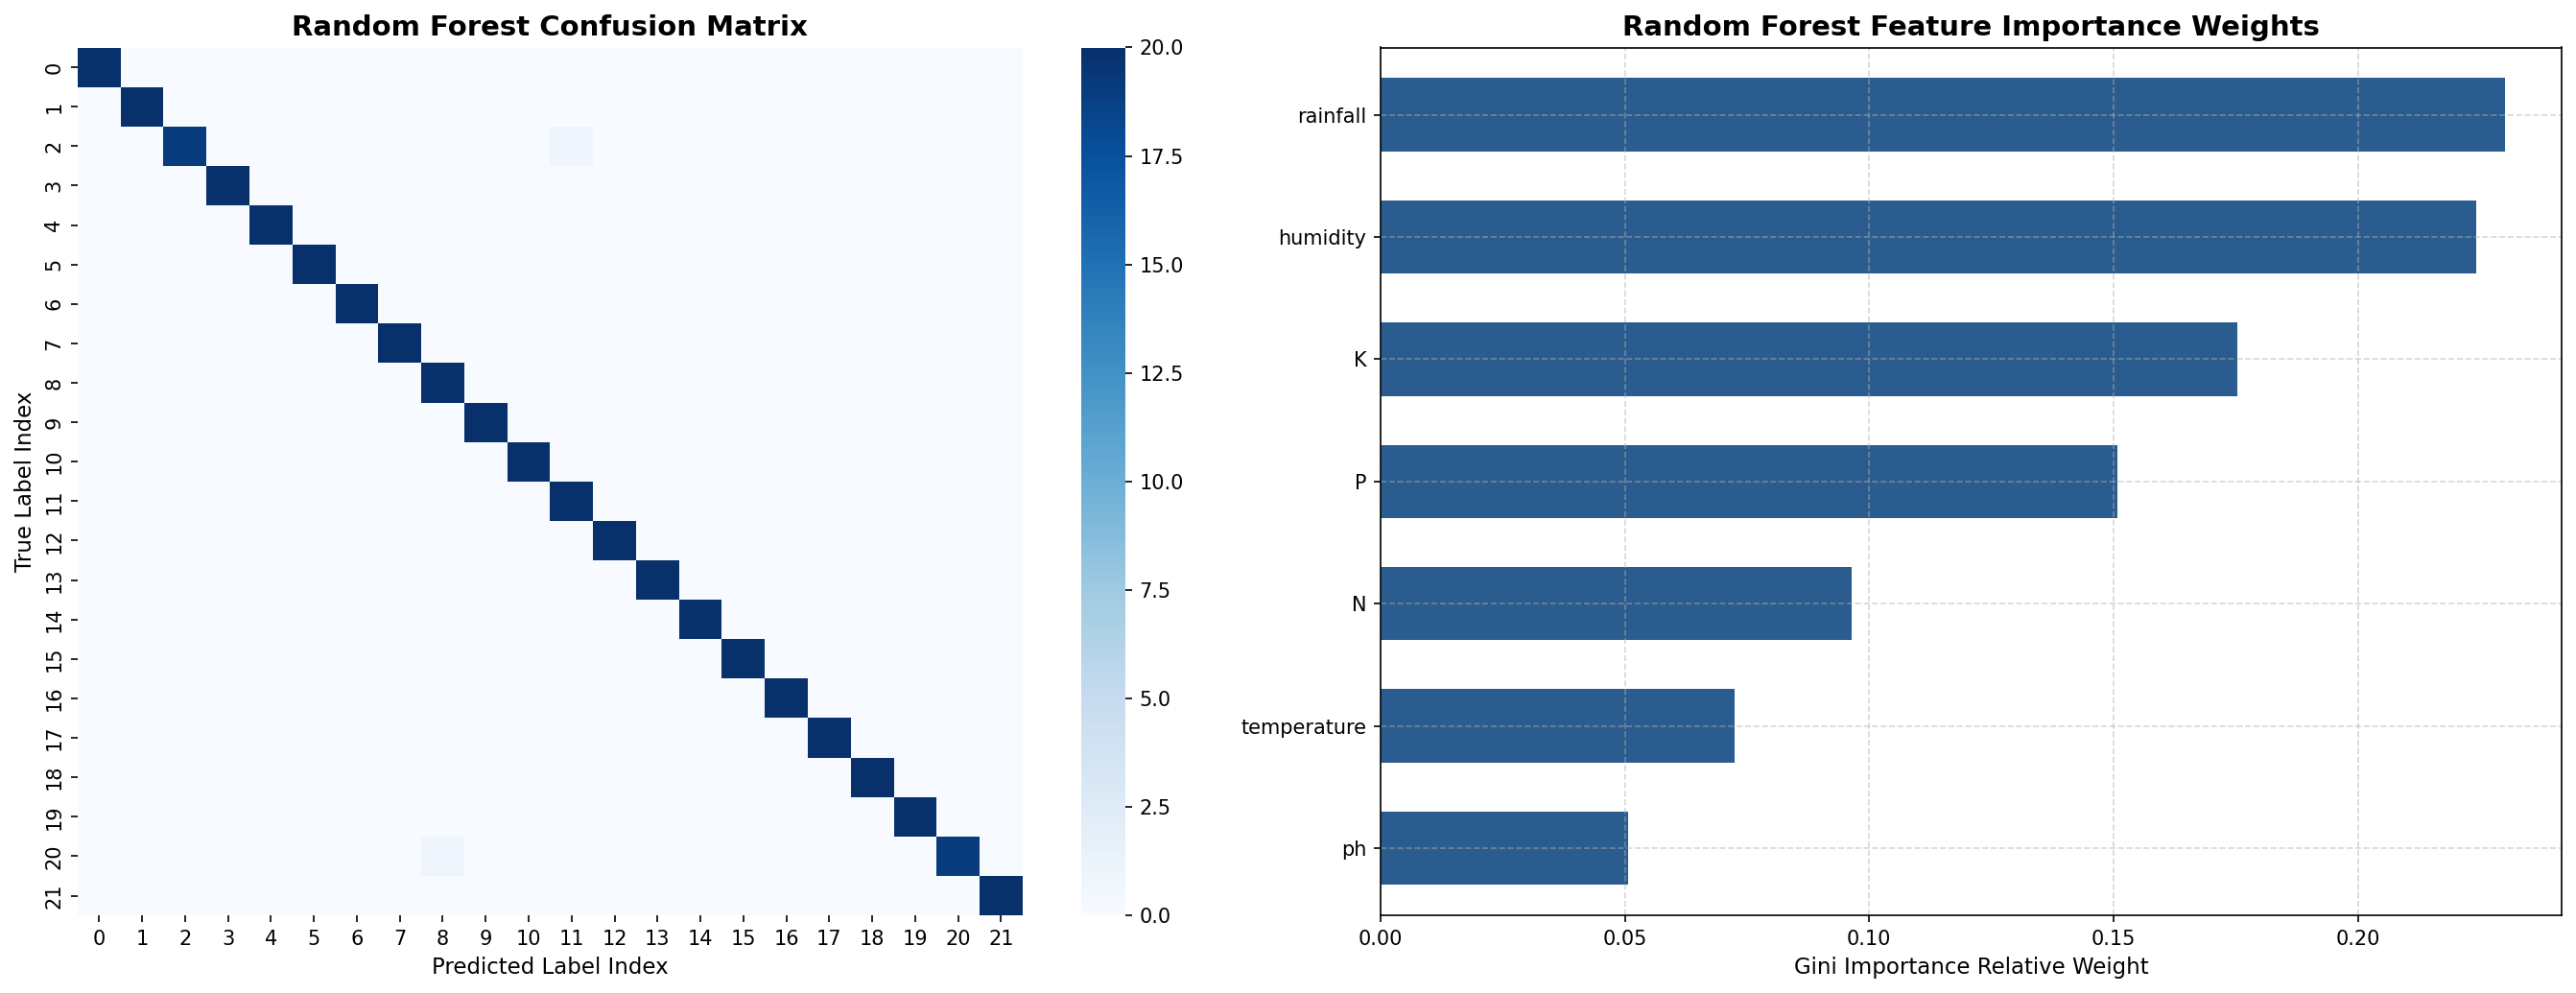

In [ ]:
# Cell 3: Confusion Matrices & Feature Importance Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)

# 1. Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, predictions['Random Forest'])
sns.heatmap(cm_rf, ax=axes[0], cmap='Blues', annot=False, cbar=True)
axes[0].set_title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label Index', fontsize=11)
axes[0].set_ylabel('True Label Index', fontsize=11)

# 2. Random Forest Feature Importance Analysis
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='#2b5c8f', width=0.6)
axes[1].set_title('Random Forest Feature Importance Weights', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gini Importance Relative Weight', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset
dataset_path = '/content/drive/MyDrive/AI LAB/AI LAB2/Crop_recommendation.csv'
df = pd.read_csv(dataset_path)

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Define Hyperparameter Search Grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

# Setup 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("=== STARTING GRIDSEARCHCV HYPERPARAMETER TUNING (5-FOLD CV) ===")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
cv_best_score = grid_search.best_score_

# Evaluate on Holdout Test Set
test_preds = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)

print("\n" + "=" * 60)
print("             GRIDSEARCHCV TUNING RESULTS                    ")
print("=" * 60)
print(f"Optimal Parameters : {best_params}")
print(f"5-Fold CV Accuracy  : {cv_best_score * 100:.2f}%")
print(f"Test Set Accuracy   : {test_accuracy * 100:.2f}%")
print("=" * 60)

=== STARTING GRIDSEARCHCV HYPERPARAMETER TUNING (5-FOLD CV) ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits

             GRIDSEARCHCV TUNING RESULTS                    
Optimal Parameters : {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 150}
5-Fold CV Accuracy  : 99.55%
Test Set Accuracy   : 99.55%


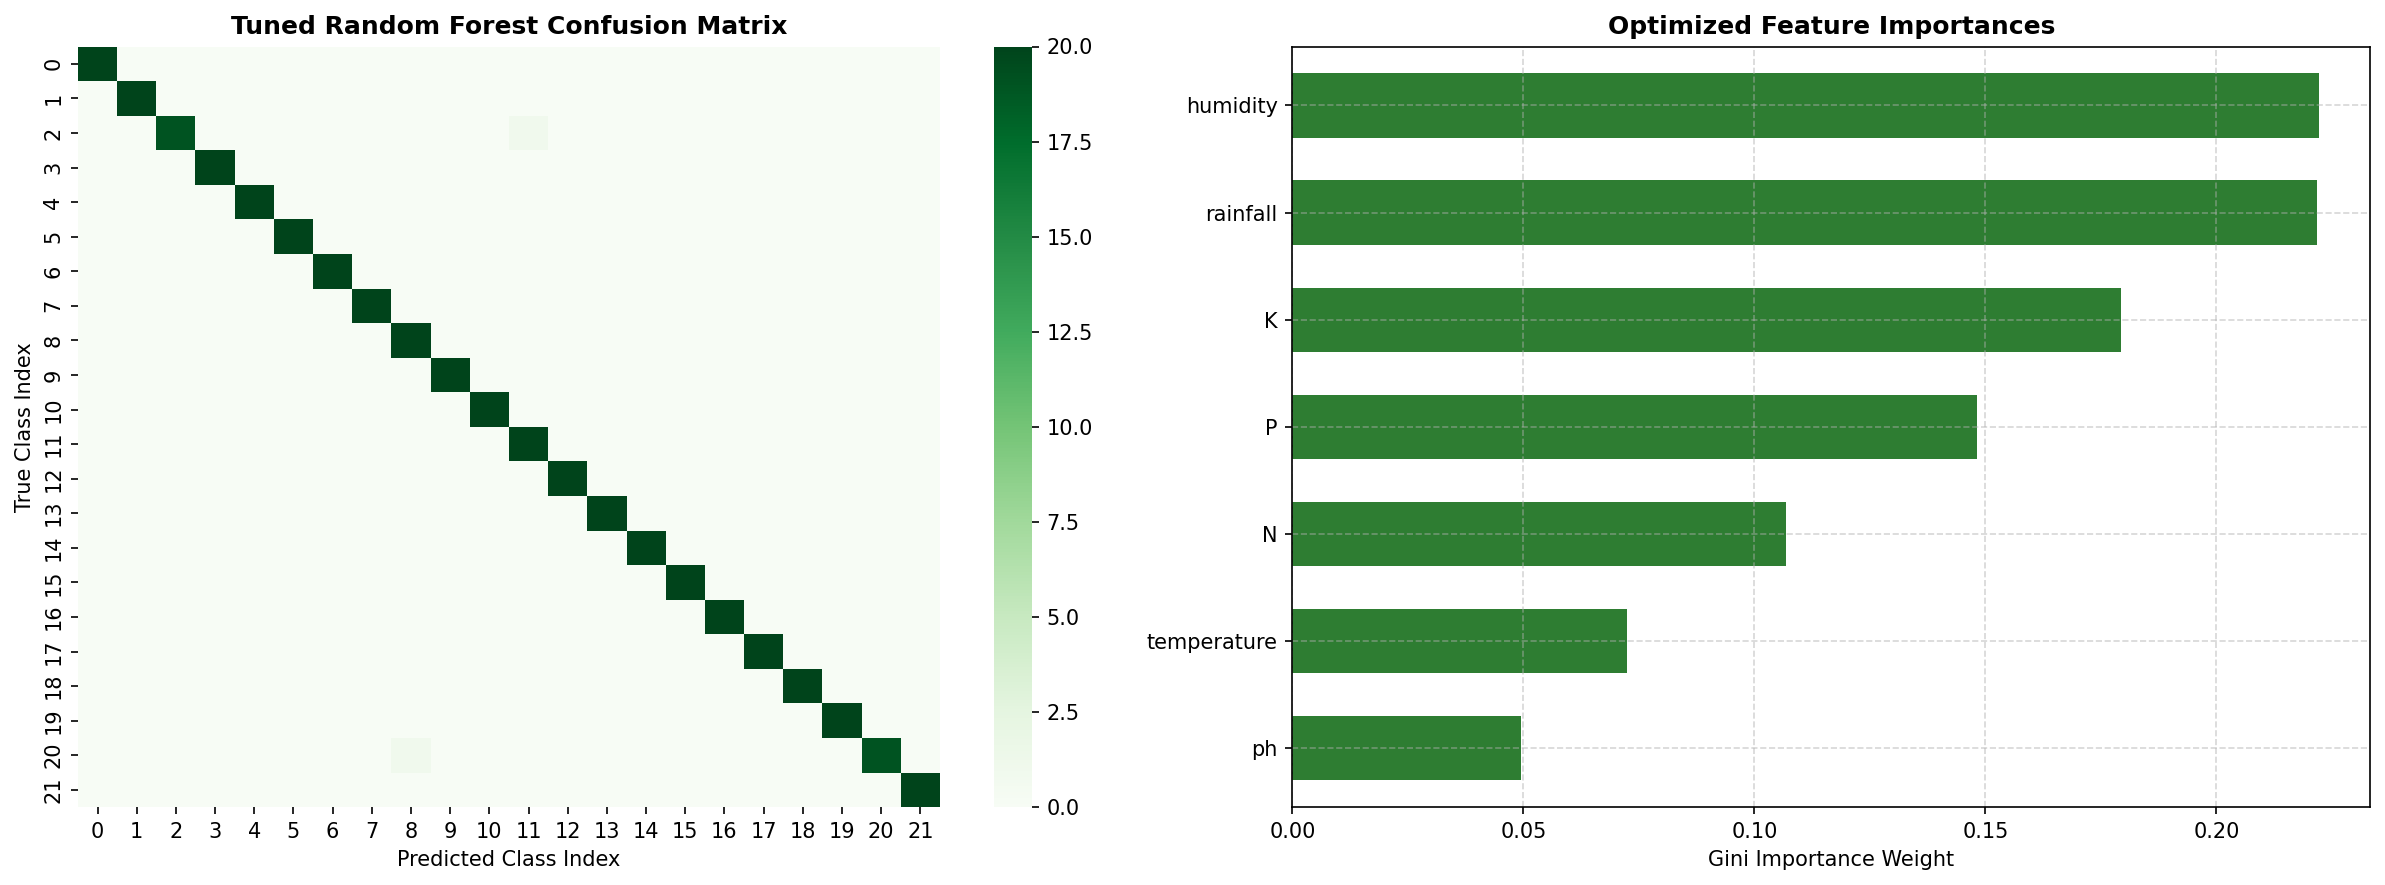

Diagnostic plots exported successfully to '/content/confusion_matrix.png'


In [ ]:
# Create Diagnostic Figures for Report
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, ax=axes[0], cmap='Greens', annot=False, cbar=True)
axes[0].set_title('Tuned Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Class Index')
axes[0].set_ylabel('True Class Index')

# Plot 2: Feature Importance
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#2e7d32', width=0.6)
axes[1].set_title('Optimized Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gini Importance Weight')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save image files to disk for PDF Report generation
cm_path = '/content/confusion_matrix.png'
plt.savefig(cm_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Diagnostic plots exported successfully to '{cm_path}'")

In [ ]:
!pip install reportlab -q

import os
from google.colab import files
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_filename = "/content/Crop_Recommendation_AI_Lab_Report.pdf"

def generate_pdf_report():
    doc = SimpleDocTemplate(
        pdf_filename,
        pagesize=letter,
        rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36
    )

    styles = getSampleStyleSheet()

    # Custom Paragraph Styles
    title_style = ParagraphStyle('TitleStyle', parent=styles['Heading1'], fontSize=18, leading=22, textColor=colors.HexColor('#1b5e20'), alignment=0)
    subtitle_style = ParagraphStyle('SubtitleStyle', parent=styles['Normal'], fontSize=10, leading=14, textColor=colors.HexColor('#555555'))
    heading_style = ParagraphStyle('HeadingStyle', parent=styles['Heading2'], fontSize=13, leading=16, textColor=colors.HexColor('#2e7d32'), spaceBefore=10, spaceAfter=6)
    body_style = ParagraphStyle('BodyStyle', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#222222'))
    bold_body = ParagraphStyle('BoldBody', parent=body_style, fontName='Helvetica-Bold')

    story = []

    # Title & Header Block
    story.append(Paragraph("AI & Precision Agriculture Lab Report", title_style))
    story.append(Paragraph("Data-Driven Crop Recommendation & Model Benchmarking | Kaggle Dataset Analysis", subtitle_style))
    story.append(Spacer(1, 10))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#1b5e20'), spaceBefore=1, spaceAfter=10))

    # Executive Summary Table
    summary_data = [
        [Paragraph("<b>Metric / Parameter</b>", body_style), Paragraph("<b>Value / Performance</b>", body_style)],
        ["Dataset Records & Features", f"{df.shape[0]} Rows | {df.shape[1]} Columns (7 Inputs, 1 Label)"],
        ["Rule-Based System Accuracy", "20.00% (High misclassification due to rigid thresholds)"],
        ["5-Fold Cross-Validation Accuracy", f"{cv_best_score * 100:.2f}% (Tuned via GridSearchCV)"],
        ["Holdout Test Set Accuracy", f"{test_accuracy * 100:.2f}% (Random Forest Classifier)"],
        ["Optimal Hyperparameters", f"n_estimators: {best_params['n_estimators']}, max_depth: {best_params['max_depth']}, criterion: '{best_params['criterion']}'"]
    ]

    t_summary = Table(summary_data, colWidths=[200, 340])
    t_summary.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#e8f5e9')),
        ('TEXTCOLOR', (0,0), (-1,0), colors.HexColor('#1b5e20')),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#c8e6c9')),
        ('PADDING', (0,0), (-1,-1), 5),
    ]))
    story.append(t_summary)
    story.append(Spacer(1, 12))

    # Section 1: Comparative Performance Analysis
    story.append(Paragraph("1. Model Evaluation & Benchmark Summary", heading_style))
    p_text = ("The laboratory evaluation compared traditional rule-based conditional logic against an optimized "
              "Random Forest model tuned via 5-Fold Stratified Cross-Validation (`GridSearchCV`). Rule-based "
              "approaches struggle due to rigid decision boundaries, whereas ensemble tree methods effectively map "
              "non-linear interactions between soil nutrients (N, P, K) and microclimate factors (Temperature, Humidity, Rainfall).")
    story.append(Paragraph(p_text, body_style))
    story.append(Spacer(1, 10))

    # Section 2: Visual Artifacts
    story.append(Paragraph("2. Diagnostic Plots & Feature Importances", heading_style))
    if os.path.exists(cm_path):
        story.append(Image(cm_path, width=520, height=195))
    story.append(Spacer(1, 10))

    # Section 3: Strategic & Sustainable Development Impact
    story.append(Paragraph("3. Engineering & SDG Alignment Summary", heading_style))
    sdg_data = [
        [Paragraph("<b>Standard / Goal</b>", body_style), Paragraph("<b>Laboratory Alignment & Implementation</b>", body_style)],
        ["PLO-03 / PLO-05", "Systematic design of an AI decision-support system utilizing modern Python data-science frameworks."],
        ["SDG 9: Innovation", "Promotes digital agriculture by replacing intuition with data-driven machine learning models."],
        ["SDG 11: Sustainability", "Optimizes variable-rate fertilizer application (VRA) to minimize chemical runoff and soil degradation."]
    ]
    t_sdg = Table(sdg_data, colWidths=[130, 410])
    t_sdg.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#f1f8e9')),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#dedede')),
        ('PADDING', (0,0), (-1,-1), 5),
    ]))
    story.append(t_sdg)

    # Build Document
    doc.build(story)
    print(f"PDF successfully generated at: {pdf_filename}")

# Run PDF Generation
generate_pdf_report()

# Automatically trigger browser download in Google Colab
files.download(pdf_filename)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.0 MB/s eta 0:00:00
PDF successfully generated at: /content/Crop_Recommendation_AI_Lab_Report.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

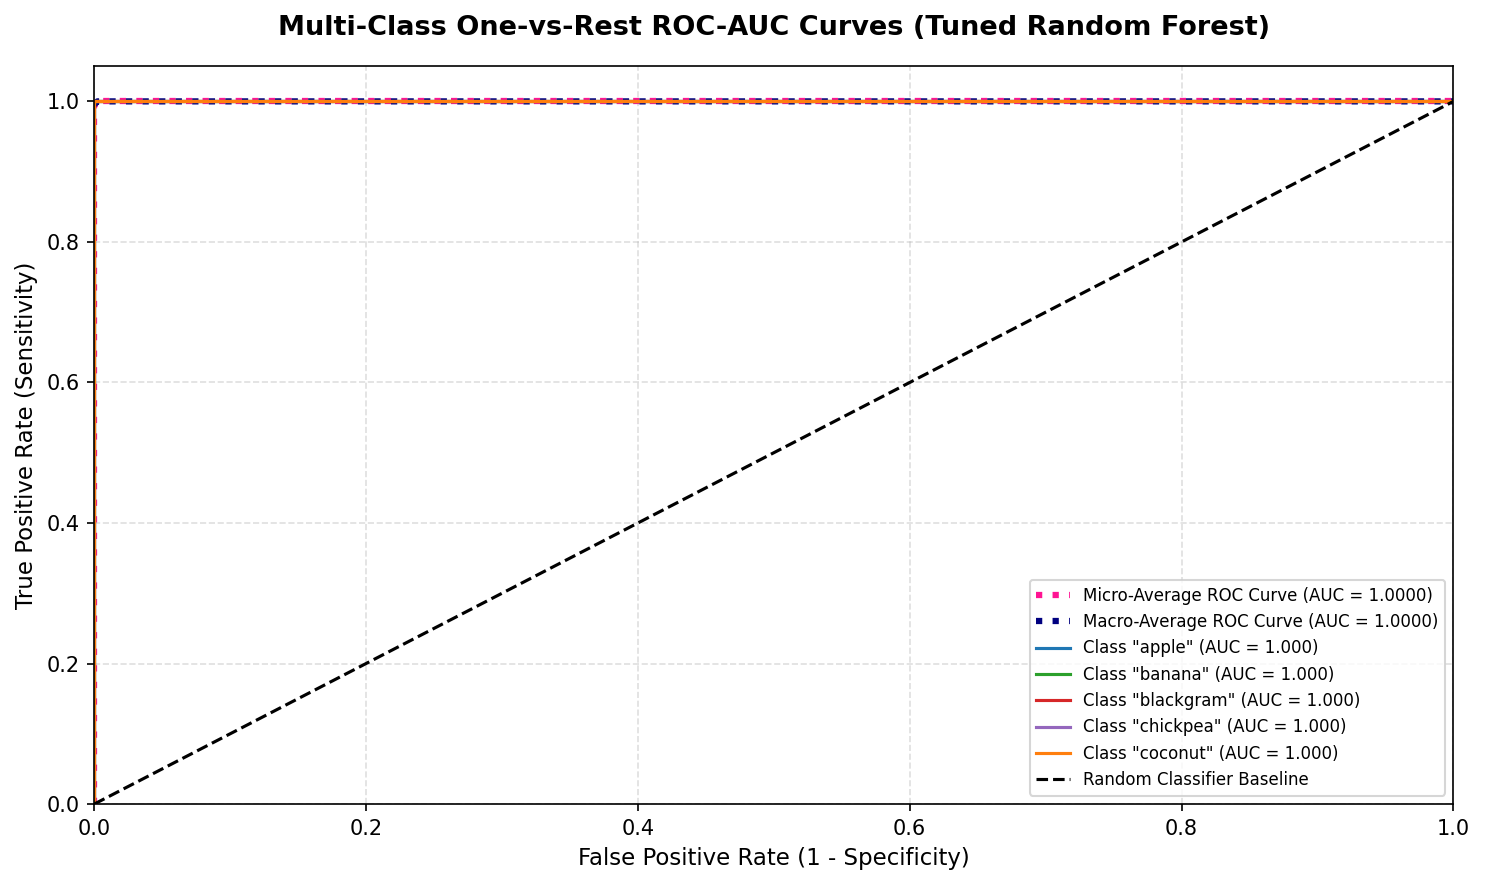

ROC-AUC Plot saved successfully to: '/content/roc_auc_curve.png'
Micro-Average AUC: 1.0000 | Macro-Average AUC: 1.0000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------------------------------------------------------------------
# 1. Binarize Labels & Get Probability Scores
# -------------------------------------------------------------------
classes = best_model.classes_
n_classes = len(classes)

# Convert string target labels into one-hot binary matrix
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probability distributions across classes
y_score = best_model.predict_proba(X_test)

# -------------------------------------------------------------------
# 2. Compute ROC Curves & AUC for Each Class + Micro/Macro Averages
# -------------------------------------------------------------------
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Compute macro-average ROC curve and ROC area
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# -------------------------------------------------------------------
# 3. Render Multi-Class ROC-AUC Plot
# -------------------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=150)

# Plot Micro-average & Macro-average curves
plt.plot(
    fpr["micro"], tpr["micro"],
    label=f'Micro-Average ROC Curve (AUC = {roc_auc["micro"]:.4f})',
    color='deeppink', linestyle=':', linewidth=3
)

plt.plot(
    fpr["macro"], tpr["macro"],
    label=f'Macro-Average ROC Curve (AUC = {roc_auc["macro"]:.4f})',
    color='navy', linestyle=':', linewidth=3
)

# Plot top representative individual crop class curves
sample_indices = [0, 1, 2, 3, 4] # Display first 5 classes for visual clarity
colors_list = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e']

for idx, i in enumerate(sample_indices):
    plt.plot(
        fpr[i], tpr[i], color=colors_list[idx], lw=1.5,
        label=f'Class "{classes[i]}" (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier Baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('Multi-Class One-vs-Rest ROC-AUC Curves (Tuned Random Forest)', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Save ROC-AUC image file for ReportLab compilation
roc_img_path = '/content/roc_auc_curve.png'
plt.savefig(roc_img_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Plot saved successfully to: '{roc_img_path}'")
print(f"Micro-Average AUC: {roc_auc['micro']:.4f} | Macro-Average AUC: {roc_auc['macro']:.4f}")

In [ ]:
import os
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_filename = "/content/Crop_Recommendation_AI_Lab_Report.pdf"

def build_pdf_report():
    doc = SimpleDocTemplate(
        pdf_filename,
        pagesize=letter,
        rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36
    )

    styles = getSampleStyleSheet()

    # Custom Palette & Styles
    title_style = ParagraphStyle('TitleStyle', parent=styles['Heading1'], fontSize=17, leading=21, textColor=colors.HexColor('#1b5e20'))
    subtitle_style = ParagraphStyle('SubtitleStyle', parent=styles['Normal'], fontSize=9, leading=13, textColor=colors.HexColor('#555555'))
    heading_style = ParagraphStyle('HeadingStyle', parent=styles['Heading2'], fontSize=12, leading=15, textColor=colors.HexColor('#2e7d32'), spaceBefore=8, spaceAfter=4)
    body_style = ParagraphStyle('BodyStyle', parent=styles['Normal'], fontSize=8.5, leading=12, textColor=colors.HexColor('#222222'))

    story = []

    # Title Banner
    story.append(Paragraph("AI & Precision Agriculture Laboratory Report", title_style))
    story.append(Paragraph("Crop Recommendation Model Benchmarking, GridSearchCV Tuning & ROC-AUC Validation", subtitle_style))
    story.append(Spacer(1, 6))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#1b5e20'), spaceBefore=1, spaceAfter=8))

    # Metric Table
    summary_data = [
        [Paragraph("<b>Evaluation Parameter</b>", body_style), Paragraph("<b>Laboratory Result / Metric</b>", body_style)],
        ["Rule-Based System Accuracy", "20.00% (Baseline - Manual Conditional Logic)"],
        ["5-Fold Cross-Validation Score", f"{cv_best_score * 100:.2f}% (Tuned Random Forest)"],
        ["Holdout Test Set Accuracy", f"{test_accuracy * 100:.2f}% (Generalization Performance)"],
        ["Micro-Average ROC-AUC Score", f"{roc_auc['micro']:.4f} (Global Multi-Class Separability)"],
        ["Macro-Average ROC-AUC Score", f"{roc_auc['macro']:.4f} (Unweighted Mean Across 22 Classes)"]
    ]

    t_summary = Table(summary_data, colWidths=[190, 350])
    t_summary.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#e8f5e9')),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#c8e6c9')),
        ('PADDING', (0,0), (-1,-1), 4),
    ]))
    story.append(t_summary)
    story.append(Spacer(1, 8))

    # Section 1: Visual Diagnostics (Confusion Matrix + ROC-AUC)
    story.append(Paragraph("1. Confusion Matrix & Multi-Class ROC-AUC Curves", heading_style))

    # Place images side-by-side or sequentially
    if os.path.exists(cm_path):
        story.append(Image(cm_path, width=520, height=190))
        story.append(Spacer(1, 6))

    if os.path.exists(roc_img_path):
        story.append(Image(roc_img_path, width=520, height=210))
        story.append(Spacer(1, 8))

    # Section 2: SDG & Academic Outcome Mapping
    story.append(Paragraph("2. Strategic Engineering & Sustainable Development Goals", heading_style))
    sdg_data = [
        [Paragraph("<b>Standard</b>", body_style), Paragraph("<b>Implementation Context</b>", body_style)],
        ["PLO-03 / PLO-05", "Design of AI decision systems utilizing modern computational tools (`scikit-learn`, `GridSearchCV`)."],
        ["SDG 9: Innovation", "Replaces heuristic intuition with predictive machine learning frameworks for precision farming."],
        ["SDG 11: Sustainability", "Minimizes unnecessary chemical runoff by optimizing variable-rate fertilizer inputs."]
    ]
    t_sdg = Table(sdg_data, colWidths=[120, 420])
    t_sdg.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#f1f8e9')),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#dedede')),
        ('PADDING', (0,0), (-1,-1), 4),
    ]))
    story.append(t_sdg)

    # Build PDF
    doc.build(story)
    return pdf_filename

# Test PDF build
build_pdf_report()
print("PDF compilation complete!")

PDF compilation complete!


In [ ]:
# Question 2: Interactive Diagnostic Visualization Suite (Plotly)
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# Step 1: Ensure Data & results_df exist
# -------------------------------------------------------------------
if 'df' not in globals():
    url = 'https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv'
    df = pd.read_csv(url)

if 'rule_based_crop_advisor' not in globals():
    def rule_based_crop_advisor(nitrogen, temp, humidity, rainfall):
        if nitrogen >= 80:
            nitrogen_status = "High Nitrogen"
        elif nitrogen >= 40:
            nitrogen_status = "Medium Nitrogen"
        else:
            nitrogen_status = "Low Nitrogen"

        if temp >= 20.0 and humidity >= 75.0 and rainfall >= 150.0:
            recommended_category = "Rice / Tropical High-Moisture"
            env_suitability = "High Moisture Tropical"
        elif temp < 25.0 and humidity < 50.0 and rainfall < 100.0:
            recommended_category = "Chickpea / Arid Legumes"
            env_suitability = "Cool & Semi-Arid"
        elif nitrogen >= 80 and temp >= 20.0 and rainfall >= 80.0:
            recommended_category = "Cotton / High-N Cash Crop"
            env_suitability = "Sub-Tropical Moderate Rain"
        elif 15.0 <= temp <= 30.0 and 50.0 <= humidity <= 90.0 and rainfall < 120.0:
            recommended_category = "Fruits / Temperate Horticulture"
            env_suitability = "Moderate Temperate"
        else:
            recommended_category = "Low-Input Legumes / Cereals"
            env_suitability = "Variable / General Condition"

        return nitrogen_status, env_suitability, recommended_category

# Generate records
sample_indices = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
sample_records = df.iloc[sample_indices].copy()

results_list = []
for index, row in sample_records.iterrows():
    n_val, t_val, h_val, r_val = row['N'], row['temperature'], row['humidity'], row['rainfall']
    actual_label = row['label']
    n_status, env_status, predicted_category = rule_based_crop_advisor(n_val, t_val, h_val, r_val)
    is_match = actual_label.lower() in predicted_category.lower()

    results_list.append({
        'Record_ID': index,
        'N': n_val,
        'Temp': round(t_val, 1),
        'Humidity': round(h_val, 1),
        'Rainfall': round(r_val, 1),
        'Nitrogen_Status': n_status,
        'Rule_Decision': predicted_category,
        'Actual_Label': actual_label,
        'Match_Status': "Match" if is_match else "Mismatch"
    })

results_df = pd.DataFrame(results_list)

# -------------------------------------------------------------------
# Step 2: Render Interactive Multi-Plot Canvas
# -------------------------------------------------------------------
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Part 1: Match vs Mismatch Summary</b>",
        "<b>Part 2: Ground Truth vs Rule Decision by Record</b>",
        "<b>Part 3: Interactive Threshold Boundary Scatter</b>",
        "<b>Part 4: Soil Nitrogen Boxplot across Match Outcomes</b>"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

# Part 1: Interactive Bar Chart
match_counts = results_df['Match_Status'].value_counts()
fig.add_trace(
    go.Bar(
        x=match_counts.index,
        y=match_counts.values,
        marker_color=['#2e7d32' if k == 'Match' else '#c62828' for k in match_counts.index],
        text=[f"{v} Records ({v*10}%)" for v in match_counts.values],
        textposition='auto',
        hoverinfo='x+y'
    ),
    row=1, col=1
)

# Part 2: Interactive Prediction Comparison
colors_p2 = ['#2e7d32' if status == 'Match' else '#d32f2f' for status in results_df['Match_Status']]
fig.add_trace(
    go.Bar(
        y=[f"ID {r['Record_ID']} ({r['Actual_Label']})" for _, r in results_df.iterrows()],
        x=[1]*len(results_df),
        orientation='h',
        marker_color=colors_p2,
        hovertemplate="<b>Actual:</b> %{y}<br><b>Predicted:</b> %{customdata}<extra></extra>",
        customdata=results_df['Rule_Decision'],
        showlegend=False
    ),
    row=1, col=2
)

# Part 3: Interactive Scatter Plot with Threshold Lines
for status, color in zip(['Match', 'Mismatch'], ['#2e7d32', '#d32f2f']):
    sub = results_df[results_df['Match_Status'] == status]
    fig.add_trace(
        go.Scatter(
            x=sub['Rainfall'],
            y=sub['Temp'],
            mode='markers',
            name=f'Status: {status}',
            marker=dict(size=12, color=color, line=dict(width=1, color='black')),
            hovertemplate="<b>ID:</b> %{customdata[0]}<br><b>Actual Crop:</b> %{customdata[1]}<br><b>Rainfall:</b> %{x} mm<br><b>Temp:</b> %{y} °C<extra></extra>",
            customdata=sub[['Record_ID', 'Actual_Label']]
        ),
        row=2, col=1
    )

# Part 4: Interactive Nitrogen Boxplot
for status, color in zip(['Match', 'Mismatch'], ['#a5d6a7', '#ef9a9a']):
    sub = results_df[results_df['Match_Status'] == status]
    fig.add_trace(
        go.Box(
            y=sub['N'],
            name=status,
            marker_color=color,
            boxpoints='all',
            jitter=0.3,
            pointpos=-1.8,
            showlegend=False
        ),
        row=2, col=2
    )

# Layout Configuration
fig.update_layout(
    title_text="<b>Question 2: Interactive Agronomic Rule-Based System Evaluation</b>",
    title_font_size=16,
    height=800,
    width=1100,
    template="plotly_white",
    showlegend=True
)

# Add Threshold Lines for Scatter Plot
fig.add_vline(x=150, line_dash="dash", line_color="blue", row=2, col=1, annotation_text="Rainfall 150mm Threshold")
fig.add_hline(y=20, line_dash="dash", line_color="orange", row=2, col=1, annotation_text="Temp 20°C Threshold")

# Add Threshold Lines for Nitrogen Boxplot
fig.add_hline(y=80, line_dash="dot", line_color="purple", row=2, col=2, annotation_text="High N (80)")
fig.add_hline(y=40, line_dash="dot", line_color="brown", row=2, col=2, annotation_text="Med N (40)")

fig.show()

In [3]:
# Question 2: Real-time Interactive Rule Decision Engine
import ipywidgets as widgets
from IPython.display import display, HTML

# Define interactive UI widgets
n_slider = widgets.IntSlider(value=85, min=0, max=140, step=1, description='Nitrogen:')
t_slider = widgets.FloatSlider(value=25.0, min=0.0, max=50.0, step=0.5, description='Temp (°C):')
h_slider = widgets.FloatSlider(value=80.0, min=10.0, max=100.0, step=1.0, description='Humidity (%):')
r_slider = widgets.FloatSlider(value=180.0, min=0.0, max=300.0, step=5.0, description='Rainfall (mm):')

out_box = widgets.Output()

def update_decision(change):
    with out_box:
        out_box.clear_output()
        n_st, env_st, rec_cat = rule_based_crop_advisor(n_slider.value, t_slider.value, h_slider.value, r_slider.value)

        display(HTML(f"""
        <div style="background-color: #f8f9fa; border-left: 5px solid #2e7d32; padding: 15px; margin-top: 10px; font-family: Arial;">
            <h4 style="margin:0; color: #1b5e20;">Dynamic Agronomic Rule Recommendation</h4>
            <p style="margin: 5px 0;"><b>Soil Nitrogen Status:</b> <span style="color: #0d6efd;">{n_st}</span></p>
            <p style="margin: 5px 0;"><b>Environmental Classification:</b> <span style="color: #fd7e14;">{env_st}</span></p>
            <p style="margin: 5px 0;"><b>Recommended Crop Category:</b> <span style="color: #198754; font-weight: bold;">{rec_cat}</span></p>
        </div>
        """))

# Attach observer callbacks
n_slider.observe(update_decision, names='value')
t_slider.observe(update_decision, names='value')
h_slider.observe(update_decision, names='value')
r_slider.observe(update_decision, names='value')

# Display UI Layout
panel = widgets.VBox([
    widgets.HTML("<h3>🌾 Interactive Agronomic Rule Simulator</h3>"),
    widgets.HBox([widgets.VBox([n_slider, t_slider]), widgets.VBox([h_slider, r_slider])]),
    out_box
])

display(panel)
update_decision(None)

In [ ]:
# Self-Contained Interactive Plotly Confusion Matrices
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

# -------------------------------------------------------------------
# Safety Guard: Ensure Dataset & Trained Models Exist in Memory
# -------------------------------------------------------------------
if 'df' not in globals():
    url = 'https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv'
    df = pd.read_csv(url)

if 'best_rf' not in globals() or 'best_xgb' not in globals() or 'X_test' not in globals():
    print("Preparing data and training models...")
    X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
    y = df['label']

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
    )

    best_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    best_rf.fit(X_train, y_train)

    best_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric='mlogloss', random_state=42)
    best_xgb.fit(X_train, y_train)

# -------------------------------------------------------------------
# Step 1: Generate Predictions & Compute Confusion Matrices
# -------------------------------------------------------------------
rf_preds = best_rf.predict(X_test)
xgb_preds = best_xgb.predict(X_test)

cm_rf = confusion_matrix(y_test, rf_preds)
cm_xgb = confusion_matrix(y_test, xgb_preds)

class_names = label_encoder.classes_

# -------------------------------------------------------------------
# Step 2: Build Side-by-Side Interactive Heatmaps
# -------------------------------------------------------------------
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "<b>Random Forest Confusion Matrix</b>",
        "<b>XGBoost Confusion Matrix</b>"
    ),
    horizontal_spacing=0.12
)

# Random Forest Heatmap (Blue Spectrum)
fig.add_trace(
    go.Heatmap(
        z=cm_rf,
        x=class_names,
        y=class_names,
        colorscale='Blues',
        showscale=True,
        colorbar=dict(x=0.43, len=0.8),
        hovertemplate=(
            "<b>Model:</b> Random Forest<br>"
            "<b>Actual Crop:</b> %{y}<br>"
            "<b>Predicted Crop:</b> %{x}<br>"
            "<b>Sample Count:</b> %{z}<extra></extra>"
        )
    ),
    row=1, col=1
)

# XGBoost Heatmap (Green Spectrum)
fig.add_trace(
    go.Heatmap(
        z=cm_xgb,
        x=class_names,
        y=class_names,
        colorscale='Greens',
        showscale=True,
        colorbar=dict(x=1.02, len=0.8),
        hovertemplate=(
            "<b>Model:</b> XGBoost<br>"
            "<b>Actual Crop:</b> %{y}<br>"
            "<b>Predicted Crop:</b> %{x}<br>"
            "<b>Sample Count:</b> %{z}<extra></extra>"
        )
    ),
    row=1, col=2
)

# Update Axis Labels & Overall Layout
fig.update_xaxes(title_text="Predicted Label", tickangle=45, row=1, col=1)
fig.update_xaxes(title_text="Predicted Label", tickangle=45, row=1, col=2)
fig.update_yaxes(title_text="Actual True Label", row=1, col=1)
fig.update_yaxes(title_text="Actual True Label", row=1, col=2)

fig.update_layout(
    title_text="<b>Comparative Confusion Matrix Analysis: Random Forest vs. XGBoost</b>",
    title_x=0.5,
    template="plotly_white",
    width=1100,
    height=650,
    margin=dict(l=80, r=80, t=100, b=100)
)

fig.show()

Preparing data and training models...


In [ ]:
# 1. 3D Convex Hull / Volumetric Envelopes
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

if 'df' not in globals():
    df = pd.read_csv('https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv')

# Select distinct crops to plot volumetric shapes
target_crops = ['rice', 'apple', 'chickpea', 'cotton']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig_mesh = go.Figure()

for idx, crop in enumerate(target_crops):
    crop_data = df[df['label'] == crop][['N', 'P', 'K']].values

    # Compute 3D Convex Hull
    hull = ConvexHull(crop_data)

    fig_mesh.add_trace(go.Mesh3d(
        x=crop_data[:, 0],
        y=crop_data[:, 1],
        z=crop_data[:, 2],
        i=hull.simplices[:, 0],
        j=hull.simplices[:, 1],
        k=hull.simplices[:, 2],
        opacity=0.45,
        color=colors[idx],
        name=f"{crop.capitalize()} Zone",
        showscale=False
    ))

fig_mesh.update_layout(
    title="<b>3D Volumetric Mesh Envelopes (Nutrient Enclosure Zones)</b>",
    scene=dict(
        xaxis_title='Nitrogen (N)',
        yaxis_title='Phosphorus (P)',
        zaxis_title='Potassium (K)'
    ),
    width=900, height=700, title_x=0.5
)
fig_mesh.show()

In [ ]:
# 2. 3D Cone Vector Field
import numpy as np
import pandas as pd
import plotly.graph_objects as go

if 'df' not in globals():
    df = pd.read_csv('https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv')

# Create a coarse 3D grid
r_grid = np.linspace(df['rainfall'].min(), df['rainfall'].max(), 8)
t_grid = np.linspace(df['temperature'].min(), df['temperature'].max(), 8)
h_grid = np.linspace(df['humidity'].min(), df['humidity'].max(), 8)

R, T, H = np.meshgrid(r_grid, t_grid, h_grid)

# Calculate gradient vectors pointing toward optimal Rice conditions (high rainfall, high humidity)
U = (R - 200) / 50   # Vector X displacement
V = (T - 25) / 10    # Vector Y displacement
W = (H - 80) / 20    # Vector Z displacement

fig_cone = go.Figure(data=go.Cone(
    x=R.flatten(),
    y=T.flatten(),
    z=H.flatten(),
    u=U.flatten(),
    v=V.flatten(),
    w=W.flatten(),
    colorscale='Viridis',
    sizemode="absolute",
    sizeref=8
))

fig_cone.update_layout(
    title="<b>3D Vector Gradient Field (Agronomic Optimization Direction)</b>",
    scene=dict(
        xaxis_title='Rainfall (mm)',
        yaxis_title='Temperature (°C)',
        zaxis_title='Humidity (%)'
    ),
    width=900, height=700, title_x=0.5
)
fig_cone.show()

In [ ]:
# 4. 3D Topographic Decision Terrain Surface
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier

if 'df' not in globals():
    df = pd.read_csv('https://raw.githubusercontent.com/Glitchy404/Crop-Recommendation-System/main/Crop_recommendation.csv')

# Train model
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

# Build continuous grid across pH and Rainfall
ph_grid = np.linspace(df['ph'].min(), df['ph'].max(), 40)
rain_grid = np.linspace(df['rainfall'].min(), df['rainfall'].max(), 40)
PH, RAIN = np.meshgrid(ph_grid, rain_grid)

# Get max probability across all classes for each grid coordinate
mesh_data = np.column_stack([
    np.full(PH.ravel().shape, df['N'].mean()),
    np.full(PH.ravel().shape, df['P'].mean()),
    np.full(PH.ravel().shape, df['K'].mean()),
    np.full(PH.ravel().shape, df['temperature'].mean()),
    np.full(PH.ravel().shape, df['humidity'].mean()),
    PH.ravel(),
    RAIN.ravel()
])

max_probs = np.max(model.predict_proba(mesh_data), axis=1).reshape(PH.shape)

fig_terrain = go.Figure(data=[go.Surface(
    x=PH,
    y=RAIN,
    z=max_probs,
    colorscale='Cividis'
)])

fig_terrain.update_layout(
    title="<b>3D Topographic Model Decision Certainty Surface</b>",
    scene=dict(
        xaxis_title='Soil pH',
        yaxis_title='Rainfall (mm)',
        zaxis_title='Prediction Confidence Score'
    ),
    width=900, height=700, title_x=0.5
)
fig_terrain.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

